In [1]:

%load_ext autoreload
%autoreload 2
from data import TriangleDataset, Style, get_dataloader, swap_expected_style_tensors
from segmentation_models_pytorch import create_model
from train_utils import train, train_probe
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from torchmetrics.segmentation.mean_iou import MeanIoU

import torch.nn as nn
import torch.nn.functional as F
import torch

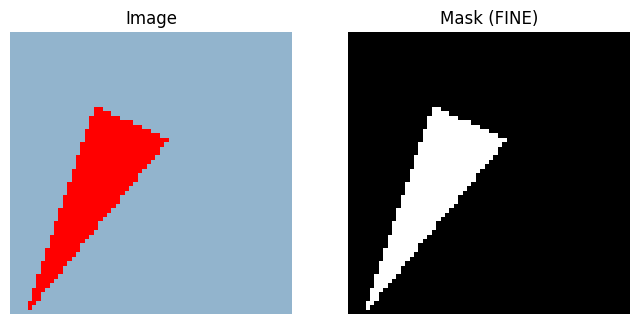

In [2]:
STYLES = [Style.COARSER, Style.FINE]
dataset = TriangleDataset(STYLES, resolution=64, n_shapes=1)
dataloader = get_dataloader(style=STYLES, resolution=64, n_shapes=1, batch_size=64)
dataset.plot()

In [3]:
model = create_model('Unet', 
                     encoder_name='resnet34',)
RETRAIN = False
ckpth = Path('./checkpoints/train_unet.pth')
ckpth.parent.mkdir(parents=True, exist_ok=True)

if not RETRAIN and ckpth.exists():
    model.load_state_dict(torch.load(ckpth))
else:
    train(dataloader, model, n_iterations=2500, device='cuda')
    torch.save(model.state_dict(), ckpth)

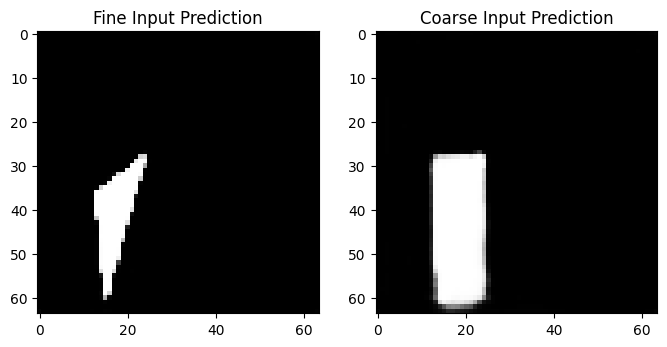

In [4]:
images, _, _ = next(iter(dataloader))
fine_images = swap_expected_style_tensors(images, Style.COARSER, Style.FINE)
coarse_images = swap_expected_style_tensors(images, Style.FINE, Style.COARSER)
model = model.cuda()
model.eval()
with torch.no_grad():
    fine_preds = model(fine_images.cuda()).sigmoid().squeeze(1).cpu()
    coarse_preds = model(coarse_images.cuda()).sigmoid().squeeze(1).cpu()
INDEX = 0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(fine_preds[INDEX], cmap='gray')
axes[0].set_title('Fine Input Prediction')
axes[1].imshow(coarse_preds[INDEX], cmap='gray')
axes[1].set_title('Coarse Input Prediction')
plt.show()

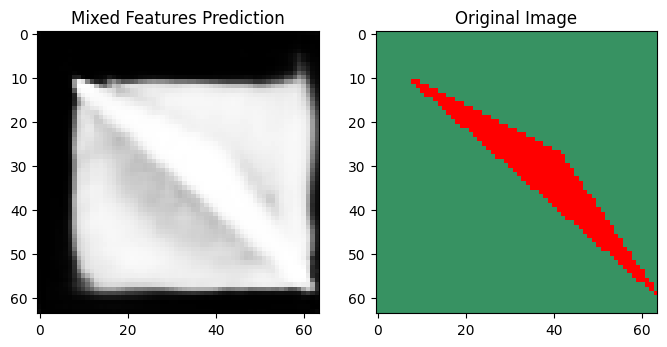

In [5]:
with torch.no_grad():
    features_fine = model.encoder(fine_images.cuda())
    features_corse = model.encoder(coarse_images.cuda())

    mixed_features = features_fine[:-1] + features_corse[-1:]
    decoder_output = model.decoder(mixed_features)
    final_output = model.segmentation_head(decoder_output).sigmoid().squeeze(1).cpu()
index = np.random.randint(0, images.shape[0]-1)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(final_output[index], cmap='gray')
axes[0].set_title('Mixed Features Prediction')
axes[1].imshow(images[index].permute(1, 2, 0), cmap='gray')
axes[1].set_title('Original Image')
plt.show()

In [6]:
# Extract the directions of changes from fine to coarse
model = model.cuda()
model.eval()
directions = None
for i in range(10):
    images, _, _ = next(iter(dataloader))
    fine_images = swap_expected_style_tensors(images, Style.COARSER, Style.FINE)
    coarse_images = swap_expected_style_tensors(images, Style.FINE, Style.COARSER)
    
    with torch.no_grad():
        fine_features = model.encoder(fine_images.cuda())[-1].mean((2,3))
        coarse_features = model.encoder(coarse_images.cuda())[-1].mean((2,3))
        
        if directions is None:
            directions = (coarse_features - fine_features).cpu()
        else:
            directions += (coarse_features - fine_features).cpu()
directions = directions.sum(0)
directions /= ((i+1) * images.shape[0])

Cosine similarity between actual and average direction: 0.9419


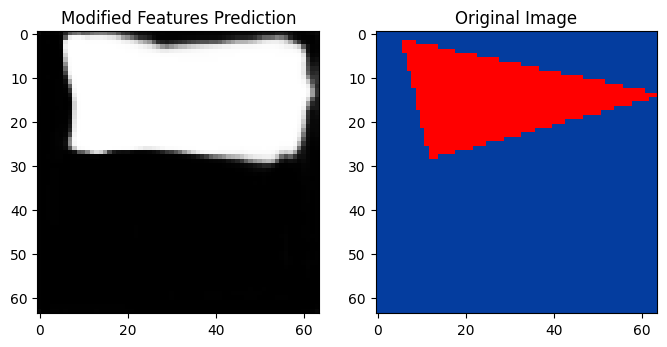

In [7]:
# # Check if the direction is constant
# images, _, _ = next(iter(dataloader))
# fine_images = swap_expected_style_tensors(images, Style.COARSE, Style.FINE)
# coarse_images = swap_expected_style_tensors(images, Style.FINE, Style.COARSE)
with torch.no_grad():
    fine_features = model.encoder(fine_images.cuda())[-1]
    coarse_features = model.encoder(coarse_images.cuda())[-1]
    
    actual_direction = (coarse_features.mean((0,2,3)) - fine_features.mean((0,2,3))).cpu()
    cos_sim = F.cosine_similarity(actual_direction.unsqueeze(0), directions.unsqueeze(0), dim=1)
    print(f'Cosine similarity between actual and average direction: {cos_sim.mean().item():.4f}')
    modified_features = fine_features.cpu() + 5*directions.view(1,-1,1,1)
    decoder_output = model.decoder([*model.encoder(fine_images.cuda())[:-1], modified_features.cuda()])
    final_output = model.segmentation_head(decoder_output).sigmoid().squeeze(1).cpu()
index = np.random.randint(0, images.shape[0]-1)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(final_output[index], cmap='gray')
axes[0].set_title('Modified Features Prediction')
axes[1].imshow(images[index].permute(1, 2, 0), cmap='gray')
axes[1].set_title('Original Image')
plt.show()

In [8]:
probe = train_probe(model, dataloader, f_index=-1, device='cuda', n_iterations=1000)

Training Probe:   0%|          | 0/1000 [00:00<?, ?it/s]

Probe Batch 100, Loss: 0.2825, Accuracy: 0.9844


c:\Users\cleme\Documents\Projects\MultiStyleSeg\notebooks\data.py:114: RuntimeWarning: invalid value encountered in sqrt
  area = np.sqrt(s * (s - a) * (s - b) * (s - c))


Probe Batch 200, Loss: 0.2369, Accuracy: 0.9531
Probe Batch 300, Loss: 0.1378, Accuracy: 0.9688
Probe Batch 300, Loss: 0.1378, Accuracy: 0.9688
Probe Batch 400, Loss: 0.1146, Accuracy: 0.9844
Probe Batch 400, Loss: 0.1146, Accuracy: 0.9844
Probe Batch 500, Loss: 0.0860, Accuracy: 1.0000
Probe Batch 500, Loss: 0.0860, Accuracy: 1.0000
Probe Batch 600, Loss: 0.0591, Accuracy: 1.0000
Probe Batch 600, Loss: 0.0591, Accuracy: 1.0000
Probe Batch 700, Loss: 0.0838, Accuracy: 0.9688
Probe Batch 700, Loss: 0.0838, Accuracy: 0.9688
Probe Batch 800, Loss: 0.0407, Accuracy: 1.0000
Probe Batch 800, Loss: 0.0407, Accuracy: 1.0000
Probe Batch 900, Loss: 0.0497, Accuracy: 0.9844
Probe Batch 900, Loss: 0.0497, Accuracy: 0.9844


In [9]:

def adversarial_perturbation(input_images, target, epsilon=0.01, alpha=0.001, n_iterations=10, device='cuda'):
    input_images = input_images.clone().detach().to(device).requires_grad_(True)
    original_images = input_images.clone().detach()
    for _ in range(n_iterations):
        outputs = model.encoder(input_images)[-1]  # (B, C, H, W)
        B, C, H, W = outputs.shape
        features = outputs.mean(dim=(2,3))  # (B, C)
        logits = probe(features).squeeze(1)  # (B)
        loss = F.binary_cross_entropy_with_logits(logits, torch.ones_like(logits) * target)
        loss.backward()
        
        with torch.no_grad():
            perturbation = alpha * input_images.grad.sign()
            input_images = input_images - perturbation
            input_images = torch.min(torch.max(input_images, original_images - epsilon), original_images + epsilon)
            input_images = input_images.clamp(0, 1).requires_grad_(True)
    return input_images.detach()
adv_images = adversarial_perturbation(fine_images, target=Style.COARSER.value>0, epsilon=0.1, alpha=0.001, n_iterations=20, device='cuda') 

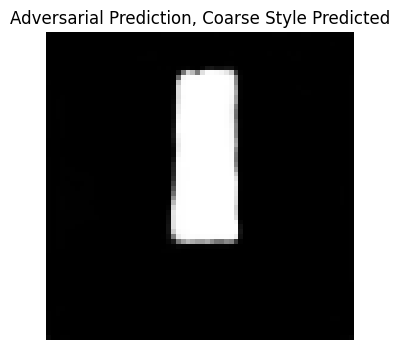

Cosine similarity between ΔF and style direction: 0.8736
Cosine similarity between gradient and style direction: -0.3146


In [10]:
# Evaluate the adversarial images
with torch.no_grad():
    adv_preds_features = model.encoder(adv_images.cuda())
    original_features = model.encoder(fine_images.cuda())[-1].mean((2,3))
    
    probe_features = adv_preds_features[-1].mean((2,3))
    
    DeltaF = probe_features - original_features
    adv_logits = probe(probe_features).squeeze(1)
    adv_preds = (adv_logits > 0).float().cpu()
    adv_preds = model.segmentation_head(model.decoder(adv_preds_features)).sigmoid().squeeze(1).cpu()

index = np.random.randint(0, images.shape[0]-1)
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.imshow(adv_preds[index], cmap='gray')
axes.set_title(f'Adversarial Prediction, {"Coarse" if adv_logits[index]>0 else "Fine"} Style Predicted')
axes.axis('off')
plt.show()

# Cosine similarity of the perturbation with the style direction
with torch.no_grad():
    cos_sim = F.cosine_similarity(DeltaF.mean(0, keepdim=True), directions.unsqueeze(0).cuda(), dim=1)
    print(f'Cosine similarity between ΔF and style direction: {cos_sim.mean().item():.4f}')

original_features = original_features.detach()
original_features.requires_grad_(True)
# Let's print the cosine similarity between the direction and the perturbation
logits = probe(original_features)
loss = F.binary_cross_entropy_with_logits(logits, torch.ones_like(logits) * (Style.COARSER.value > 0))
loss.backward()
with torch.no_grad():
    gradient = original_features.grad
    cos_sim = F.cosine_similarity(gradient.mean(0, keepdim=True), directions.unsqueeze(0).cuda(), dim=1)
    print(f'Cosine similarity between gradient and style direction: {cos_sim.mean().item():.4f}')


In [11]:
from torch.autograd.functional import jvp

def compute_Gw(encoder, x, w):
    """
    Compute G @ w = J_E @ J_E^T @ w efficiently.
    
    Uses backward-mode AD for J^T @ w, then forward-mode AD for J @ (J^T @ w).
    """
    
    def encoder_pooled(inp):
        features = encoder(inp)[-1]  # [B, C, H, W]
        return features.mean(dim=(0, 2, 3))  # [C]
    
    # Step 1: Compute v = J_E^T @ w via standard backward pass
    x_grad = x.clone().requires_grad_(True)
    f = encoder_pooled(x_grad)
    
    # grad of (w · f) w.r.t. x gives J_E^T @ w
    v = torch.autograd.grad((f * w).sum(), x_grad)[0]  # [B, C_in, H, W]
    
    # Step 2: Compute Gw = J_E @ v via forward-mode AD (jvp)
    x_detached = x.clone().detach()
    _, Gw = jvp(encoder_pooled, (x_detached,), (v.detach(),))
    
    return Gw

# Usage
model.eval()
w = probe.weight.squeeze().detach().cuda()
Gw = compute_Gw(model.encoder, fine_images.cuda(), w)

# Compare with adversarial Δf
cos_Gw_deltaF = F.cosine_similarity(Gw.unsqueeze(0), DeltaF.mean(0).unsqueeze(0), dim=1)
cos_Gw_directions = F.cosine_similarity(Gw.unsqueeze(0), directions.unsqueeze(0).cuda(), dim=1)

print(f"Gw ↔ Adversarial Δf: {cos_Gw_deltaF.item():.4f}")  # Should be ~1.0
print(f"Gw ↔ Style direction: {cos_Gw_directions.item():.4f}")  # Should match Δf ↔ style

Gw ↔ Adversarial Δf: 0.1880
Gw ↔ Style direction: 0.6000


In [12]:
def compute_Gv(encoder, x, v):
    """Compute G @ v = J_E @ J_E^T @ v for any vector v."""
    
    def encoder_pooled(inp):
        features = encoder(inp)[-1]
        return features.mean(dim=(0, 2, 3))
    
    x_grad = x.clone().requires_grad_(True)
    f = encoder_pooled(x_grad)
    
    # J_E^T @ v
    jTv = torch.autograd.grad((f * v).sum(), x_grad)[0]
    
    # J_E @ (J_E^T @ v)
    x_detached = x.clone().detach()
    _, Gv = jvp(encoder_pooled, (x_detached,), (jTv.detach(),))
    
    return Gv

def power_iteration_G(encoder, x, n_iters=50):
    """Find top singular vector of G = J_E @ J_E^T via power iteration."""
    
    # Initialize random vector in feature space
    C = 512  # feature channels
    v = torch.randn(C, device=x.device)
    v = v / v.norm()
    
    eigenvalues = []
    
    for i in range(n_iters):
        # Compute G @ v
        Gv = compute_Gv(encoder, x, v)
        
        # Eigenvalue estimate (Rayleigh quotient)
        eigenvalue = (v * Gv).sum()
        eigenvalues.append(eigenvalue.item())
        
        # Normalize for next iteration
        v_new = Gv / Gv.norm()
        
        # Check convergence
        if i > 0:
            cos_sim = F.cosine_similarity(v.unsqueeze(0), v_new.unsqueeze(0)).item()
            if cos_sim > 0.999999:
                print(f"Converged at iteration {i}")
                break
        
        v = v_new
    
    return v, eigenvalues

# Run power iteration
model.eval()
top_singular_vec, eigenvalues = power_iteration_G(model.encoder, fine_images.cuda(), n_iters=50)

# Compare with our directions
w = probe.weight.squeeze().detach().cuda()

cos_top_style = F.cosine_similarity(top_singular_vec.unsqueeze(0), directions.cuda().unsqueeze(0), dim=1)
cos_top_probe = F.cosine_similarity(top_singular_vec.unsqueeze(0), w.unsqueeze(0), dim=1)
cos_top_Gw = F.cosine_similarity(top_singular_vec.unsqueeze(0), Gw.unsqueeze(0), dim=1)

print(f"Top singular vector ↔ Style direction: {cos_top_style.item():.4f}")
print(f"Top singular vector ↔ Probe direction: {cos_top_probe.item():.4f}")
print(f"Top singular vector ↔ Gw: {cos_top_Gw.item():.4f}")

# Also compute singular values for style vs probe directions
# σ²(v) = v^T G v / ||v||² = ||G v|| when v is unit norm
style_normalized = directions.cuda() / directions.cuda().norm()
probe_normalized = w / w.norm()

G_style = compute_Gv(model.encoder, fine_images.cuda(), style_normalized)
G_probe = compute_Gv(model.encoder, fine_images.cuda(), probe_normalized)

sigma_sq_style = (style_normalized * G_style).sum()
sigma_sq_probe = (probe_normalized * G_probe).sum()

print(f"\nSingular value² (style direction): {sigma_sq_style.item():.4f}")
print(f"Singular value² (probe direction): {sigma_sq_probe.item():.4f}")
print(f"Ratio σ²(style)/σ²(probe): {(sigma_sq_style/sigma_sq_probe).item():.4f}")

Converged at iteration 2
Top singular vector ↔ Style direction: 0.5702
Top singular vector ↔ Probe direction: 0.0185
Top singular vector ↔ Gw: 0.9987

Singular value² (style direction): 3729.2544
Singular value² (probe direction): 6.7788
Ratio σ²(style)/σ²(probe): 550.1332


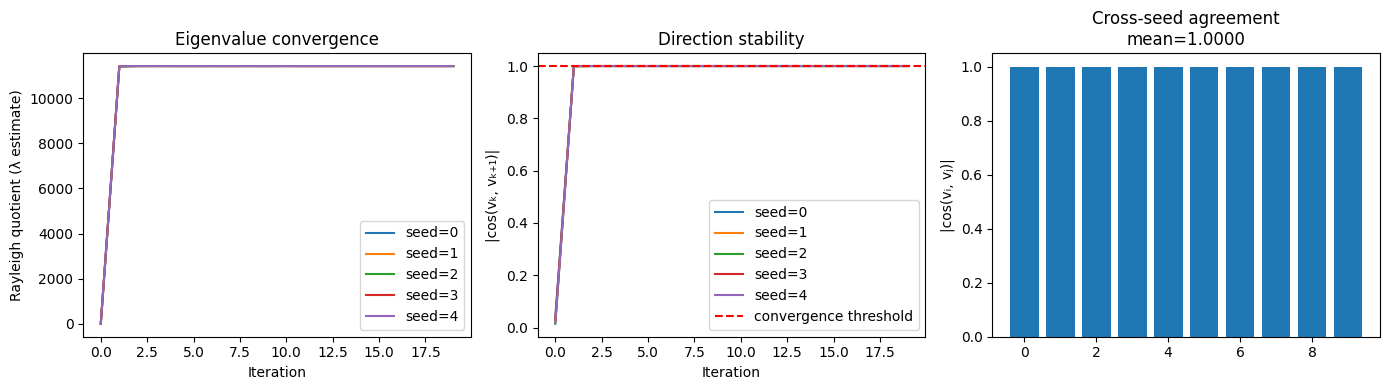


--- Eigenvalue spectrum probe ---
Random direction Rayleighs: min=1.39, max=266.34, mean=53.90
Top eigenvector Rayleigh: 11419.61
Ratio top/mean_random: 211.9x

This suggests G has LOW effective rank
Random direction Rayleighs: min=1.39, max=266.34, mean=53.90
Top eigenvector Rayleigh: 11419.61
Ratio top/mean_random: 211.9x

This suggests G has LOW effective rank


In [13]:
# Diagnose why power iteration converges so fast
# Check: eigenvalue spectrum, initial alignment, multiple seeds

def power_iteration_detailed(encoder, x, n_iters=50, seed=None):
    """Power iteration with detailed diagnostics."""
    C = 512
    if seed is not None:
        torch.manual_seed(seed)
    v = torch.randn(C, device=x.device)
    v = v / v.norm()
    
    eigenvalues = []
    cosines_to_prev = []
    
    for i in range(n_iters):
        Gv = compute_Gv(encoder, x, v)
        eigenvalue = (v * Gv).sum().item()
        eigenvalues.append(eigenvalue)
        
        v_new = Gv / (Gv.norm() + 1e-8)
        cos_sim = F.cosine_similarity(v.unsqueeze(0), v_new.unsqueeze(0)).item()
        cosines_to_prev.append(abs(cos_sim))
        
        v = v_new
    
    return v, eigenvalues, cosines_to_prev

# Run with multiple seeds
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_top_vecs = []
for seed in range(5):
    v_final, eigs, cosines = power_iteration_detailed(model.encoder, fine_images.cuda(), n_iters=20, seed=seed)
    all_top_vecs.append(v_final)
    axes[0].plot(eigs, label=f'seed={seed}')
    axes[1].plot(cosines, label=f'seed={seed}')

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Rayleigh quotient (λ estimate)')
axes[0].set_title('Eigenvalue convergence')
axes[0].legend()

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('|cos(vₖ, vₖ₊₁)|')
axes[1].set_title('Direction stability')
axes[1].axhline(0.9999, color='r', linestyle='--', label='convergence threshold')
axes[1].legend()

# Check consistency across seeds
cross_cosines = []
for i in range(len(all_top_vecs)):
    for j in range(i+1, len(all_top_vecs)):
        cc = abs(F.cosine_similarity(all_top_vecs[i].unsqueeze(0), all_top_vecs[j].unsqueeze(0)).item())
        cross_cosines.append(cc)

axes[2].bar(range(len(cross_cosines)), cross_cosines)
axes[2].set_ylabel('|cos(vᵢ, vⱼ)|')
axes[2].set_title(f'Cross-seed agreement\nmean={np.mean(cross_cosines):.4f}')
axes[2].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Also check: is G nearly rank-1?
# Compute Rayleigh quotients for random orthogonal directions
print("\n--- Eigenvalue spectrum probe ---")
n_probes = 10
rayleighs = []
for _ in range(n_probes):
    rand_v = torch.randn(512, device='cuda')
    rand_v = F.normalize(rand_v, dim=0)
    Gv = compute_Gv(model.encoder, fine_images.cuda(), rand_v)
    rayleigh = (rand_v * Gv).sum().item()
    rayleighs.append(rayleigh)

print(f"Random direction Rayleighs: min={min(rayleighs):.2f}, max={max(rayleighs):.2f}, mean={np.mean(rayleighs):.2f}")
print(f"Top eigenvector Rayleigh: {eigenvalues[-1]:.2f}")
print(f"Ratio top/mean_random: {eigenvalues[-1]/np.mean(rayleighs):.1f}x")
print(f"\nThis suggests G has {'LOW' if eigenvalues[-1]/np.mean(rayleighs) > 10 else 'MODERATE'} effective rank")

In [14]:
from copy import deepcopy
STYLES = [Style.COARSER, Style.FINE]
model_sequential = create_model('Unet', 
                     encoder_name='resnet34',)
dataloader_fine = get_dataloader(style=Style.FINE, resolution=64, n_shapes=1, batch_size=64)
dataloader_coarse = get_dataloader(style=Style.COARSER, resolution=64, n_shapes=1, batch_size=64)

train(dataloader_fine, model_sequential, n_iterations=2500, device='cuda')
# Deep copy the state_dict
fine_state_dict = deepcopy(model_sequential.state_dict())

train(dataloader_coarse, model_sequential, n_iterations=2500, device='cuda')


Training:   0%|          | 0/2500 [00:00<?, ?it/s]

Batch 100, Loss: 0.9145, Dice Score: 0.8392
Batch 200, Loss: 0.7190, Dice Score: 0.9041
Batch 200, Loss: 0.7190, Dice Score: 0.9041
Batch 300, Loss: 0.5680, Dice Score: 0.9403
Batch 300, Loss: 0.5680, Dice Score: 0.9403
Batch 400, Loss: 0.3713, Dice Score: 0.9577
Batch 400, Loss: 0.3713, Dice Score: 0.9577
Batch 500, Loss: 0.2524, Dice Score: 0.9781
Batch 500, Loss: 0.2524, Dice Score: 0.9781
Batch 600, Loss: 0.2217, Dice Score: 0.9880
Batch 600, Loss: 0.2217, Dice Score: 0.9880
Batch 700, Loss: 0.1611, Dice Score: 0.9900
Batch 700, Loss: 0.1611, Dice Score: 0.9900
Batch 800, Loss: 0.1226, Dice Score: 0.9893
Batch 800, Loss: 0.1226, Dice Score: 0.9893
Batch 900, Loss: 0.1244, Dice Score: 0.9888
Batch 900, Loss: 0.1244, Dice Score: 0.9888
Batch 1000, Loss: 0.0936, Dice Score: 0.9932
Batch 1000, Loss: 0.0936, Dice Score: 0.9932
Batch 1100, Loss: 0.0969, Dice Score: 0.9942
Batch 1100, Loss: 0.0969, Dice Score: 0.9942
Batch 1200, Loss: 0.0676, Dice Score: 0.9843
Batch 1200, Loss: 0.0676, D

Training:   0%|          | 0/2500 [00:00<?, ?it/s]

Batch 100, Loss: 0.1783, Dice Score: 0.9433
Batch 200, Loss: 0.1335, Dice Score: 0.9581
Batch 200, Loss: 0.1335, Dice Score: 0.9581
Batch 300, Loss: 0.0991, Dice Score: 0.9432
Batch 300, Loss: 0.0991, Dice Score: 0.9432
Batch 400, Loss: 0.1030, Dice Score: 0.9725
Batch 400, Loss: 0.1030, Dice Score: 0.9725
Batch 500, Loss: 0.0723, Dice Score: 0.9795
Batch 500, Loss: 0.0723, Dice Score: 0.9795
Batch 600, Loss: 0.0937, Dice Score: 0.9740
Batch 600, Loss: 0.0937, Dice Score: 0.9740
Batch 700, Loss: 0.0560, Dice Score: 0.9740
Batch 700, Loss: 0.0560, Dice Score: 0.9740
Batch 800, Loss: 0.0561, Dice Score: 0.9662
Batch 800, Loss: 0.0561, Dice Score: 0.9662
Batch 900, Loss: 0.0429, Dice Score: 0.9582
Batch 900, Loss: 0.0429, Dice Score: 0.9582
Batch 1000, Loss: 0.0463, Dice Score: 0.9783
Batch 1000, Loss: 0.0463, Dice Score: 0.9783
Batch 1100, Loss: 0.0417, Dice Score: 0.9895
Batch 1100, Loss: 0.0417, Dice Score: 0.9895
Batch 1200, Loss: 0.0387, Dice Score: 0.9896
Batch 1200, Loss: 0.0387, D

0.06518666229620576

In [15]:
fine_model = create_model('Unet', 
                     encoder_name='resnet34',)
fine_model.load_state_dict(fine_state_dict)
model.eval()
fine_model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

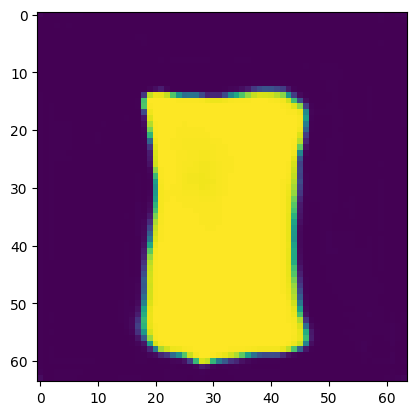

In [16]:
input_fine, _, _ = next(iter(dataloader_fine))

with torch.no_grad():
    features = model.encoder(input_fine.cuda())
    
    last_features = features[-1] + 3.5* directions.view(1,-1,1,1).cuda()
    features[-1] = last_features
    pred = model.decoder(features)
    pred = model.segmentation_head(pred).sigmoid().squeeze(1).cpu()
   
   
index = np.random.randint(0, pred.shape[0])
plt.imshow(pred[index])
plt.show()

In [17]:
# Get features from both models on the SAME inputs
fine_images, _, _ = next(iter(dataloader_fine))
fine_images = fine_images.cuda()

model_fine_only = fine_model.cuda()
# Features before and after forgetting
model_fine_only.eval()
model_sequential.eval()

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)[-1]  # [B, C, H, W]
    f_after = model_sequential.encoder(fine_images)[-1]   # [B, C, H, W]

# Compute the shift in feature space
delta_f = f_after - f_before  # [B, C, H, W]

# Pool spatially to get channel-wise shift
delta_f_pooled = delta_f.mean(dim=(2, 3))  # [B, C]

# Is this shift consistent across images? (low-rank check)
# Compute mean direction
mean_shift = delta_f_pooled.mean(dim=0)  # [C]
mean_shift_normalized = mean_shift / mean_shift.norm()

# Check consistency: how aligned is each image's shift with the mean?
per_image_alignment = F.cosine_similarity(
    delta_f_pooled, 
    mean_shift.unsqueeze(0).expand_as(delta_f_pooled), 
    dim=1
)
print(f"=== Forgetting Direction Analysis ===\n")
print(f"Shift magnitude: {mean_shift.norm().item():.4f}")
print(f"Per-image alignment with mean shift: {per_image_alignment.mean().item():.4f} ± {per_image_alignment.std().item():.4f}")

# SVD of the shift matrix to check rank
U, S, V = torch.linalg.svd(delta_f_pooled)
S_normalized = S / S.sum()
print(f"\nTop 5 singular values (normalized): {S_normalized[:5].tolist()}")
print(f"Rank-1 explains: {S_normalized[0].item()*100:.1f}% of variance")
print(f"Rank-3 explains: {S_normalized[:3].sum().item()*100:.1f}% of variance")

=== Forgetting Direction Analysis ===

Shift magnitude: 6.1678
Per-image alignment with mean shift: 0.2822 ± 0.1359

Top 5 singular values (normalized): [0.32325759530067444, 0.10427793115377426, 0.05730822682380676, 0.044394005089998245, 0.036405619233846664]
Rank-1 explains: 32.3% of variance
Rank-3 explains: 48.5% of variance


In [18]:
# The hypothesis: subtracting the forgetting direction restores fine behavior

def decode_with_offset(model, features_bhw, offset_c):
    """
    Run decoder on modified features.
    offset_c is [C], broadcast to [B, C, H, W]
    """
    # Add offset to bottleneck features
    modified = features_bhw + offset_c.view(1, -1, 1, 1)
    
    # Run through decoder
    # Need to get skip connections from encoder first
    return model.decoder(modified)  # This depends on your architecture

# Simpler approach: patch the forward pass
class FeatureOffsetWrapper(torch.nn.Module):
    def __init__(self, model, offset, layer='bottleneck'):
        super().__init__()
        self.model = model
        self.offset = offset  # [C]
        
    def forward(self, x):
        # Get encoder features
        features = self.model.encoder(x)
        
        # Modify bottleneck (last encoder output)
        features[-1] = features[-1] - self.offset.view(1, -1, 1, 1)
        
        # Decode with modified features
        decoded = self.model.decoder(features)
        return self.model.segmentation_head(decoded)

# Create corrected model
forgetting_direction = mean_shift  # [C]
corrected_model = FeatureOffsetWrapper(model_sequential, forgetting_direction)

# Evaluate
print("\n=== Forgetting Reversal ===\n")

mean_iou = MeanIoU(num_classes=1).cuda()


def quick_eval(model, images, masks):
    model.eval()
    with torch.no_grad():
        pred = model(images).sigmoid() > 0.5
        iou = mean_iou(pred, masks > 0)
    return iou.item()

fine_images, fine_masks, _ = next(iter(dataloader_fine))
fine_images, fine_masks= fine_images.cuda(), fine_masks.cuda()

iou_original = quick_eval(model_fine_only, fine_images, fine_masks)
iou_forgotten = quick_eval(model_sequential, fine_images, fine_masks)
iou_corrected = quick_eval(corrected_model, fine_images, fine_masks)

print(f"Fine-only model (target):     IoU = {iou_original:.4f}")
print(f"Sequential model (forgotten): IoU = {iou_forgotten:.4f}")
print(f"Corrected model (restored?):  IoU = {iou_corrected:.4f}")


=== Forgetting Reversal ===

Fine-only model (target):     IoU = 0.9913
Sequential model (forgotten): IoU = 0.3669
Corrected model (restored?):  IoU = 0.3656
Fine-only model (target):     IoU = 0.9913
Sequential model (forgotten): IoU = 0.3669
Corrected model (restored?):  IoU = 0.3656



=== Correction Strength Scan ===

α = 0.00: IoU = 0.3669
α = 0.25: IoU = 0.3669
α = 0.50: IoU = 0.3665
α = 0.75: IoU = 0.3660
α = 1.00: IoU = 0.3656
α = 1.25: IoU = 0.3651

α = 0.00: IoU = 0.3669
α = 0.25: IoU = 0.3669
α = 0.50: IoU = 0.3665
α = 0.75: IoU = 0.3660
α = 1.00: IoU = 0.3656
α = 1.25: IoU = 0.3651
α = 1.50: IoU = 0.3649
α = 2.00: IoU = 0.3649
α = 1.50: IoU = 0.3649
α = 2.00: IoU = 0.3649


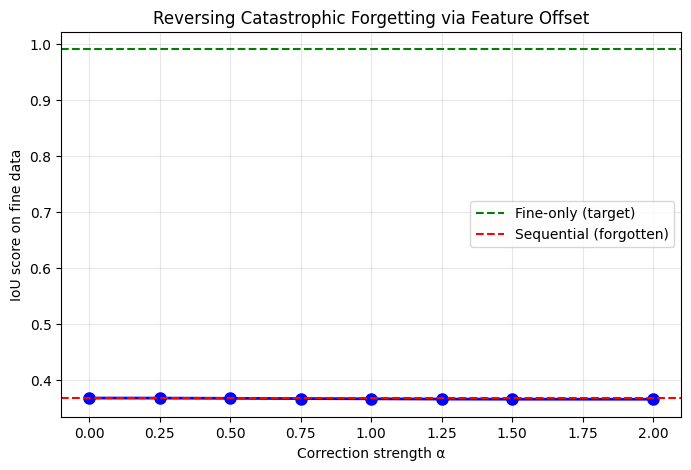

In [19]:
# Scan different correction strengths
print("\n=== Correction Strength Scan ===\n")

alphas = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
results = []

for alpha in alphas:
    corrected = FeatureOffsetWrapper(model_sequential, alpha * forgetting_direction)
    iou = quick_eval(corrected, fine_images, fine_masks)
    results.append(iou)
    print(f"α = {alpha:.2f}: IoU = {iou:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(alphas, results, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=iou_original, color='g', linestyle='--', label='Fine-only (target)')
plt.axhline(y=iou_forgotten, color='r', linestyle='--', label='Sequential (forgotten)')
plt.xlabel('Correction strength α')
plt.ylabel('IoU score on fine data')
plt.title('Reversing Catastrophic Forgetting via Feature Offset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Cross-model decoding
def encode_decode_cross(encoder_model, decoder_model, x):
    features = encoder_model.encoder(x)
    decoded = decoder_model.decoder(features) 
    return decoder_model.segmentation_head(decoded)

fine_images, fine_masks, _ = next(iter(dataloader_fine))
fine_images, fine_masks = fine_images.cuda(), fine_masks.cuda()

model_fine_only.eval()
model_sequential.eval()

with torch.no_grad():
    pred_fine_fine = model_fine_only(fine_images) > 0.0
    pred_seq_seq = model_sequential(fine_images)> 0.0
    pred_fine_enc_seq_dec = encode_decode_cross(model_fine_only, model_sequential, fine_images) > 0.0
    pred_seq_enc_fine_dec = encode_decode_cross(model_sequential, model_fine_only, fine_images)> 0.0

print("=== Cross-Model Decoding ===\n")
print(f"Fine enc + Fine dec (target):    IoU = {mean_iou(pred_fine_fine, fine_masks.long()):.4f}")
print(f"Seq enc  + Seq dec  (forgotten): IoU = {mean_iou(pred_seq_seq, fine_masks.long()):.4f}")
print(f"Fine enc + Seq dec:              IoU = {mean_iou(pred_fine_enc_seq_dec, fine_masks.long()):.4f}")
print(f"Seq enc  + Fine dec:             IoU = {mean_iou(pred_seq_enc_fine_dec, fine_masks.long()):.4f}")

=== Cross-Model Decoding ===

Fine enc + Fine dec (target):    IoU = 0.9932
Seq enc  + Seq dec  (forgotten): IoU = 0.3925
Fine enc + Seq dec:              IoU = 0.3877
Seq enc  + Fine dec:             IoU = 0.9727


In [21]:
# Can we correct the encoder drift to fully recover?
# Seq encoder + correction → Fine decoder

class CorrectedCrossModel(torch.nn.Module):
    def __init__(self, seq_encoder, fine_decoder, seg_head, offset):
        super().__init__()
        self.encoder = seq_encoder
        self.decoder = fine_decoder
        self.seg_head = seg_head
        self.offset = offset
    
    def forward(self, x):
        features = self.encoder(x)
        features[-1] = features[-1] - self.offset.view(1, -1, 1, 1)
        decoded = self.decoder(features)
        return self.seg_head(decoded) > 0.

print("=== Corrected Encoder + Fine Decoder ===\n")
print(f"Target (Fine+Fine):           IoU = {mean_iou(pred_fine_fine, fine_masks.long()):.4f}")
print(f"Uncorrected (Seq+Fine):       IoU = {mean_iou(pred_seq_enc_fine_dec, fine_masks.long()):.4f}")
print()

for alpha in [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 3, 3.5]:
    corrected = CorrectedCrossModel(
        model_sequential.encoder,
        model_fine_only.decoder, 
        model_fine_only.segmentation_head,
        alpha * mean_shift
    )
    with torch.no_grad():
        pred = corrected(fine_images)
    print(f"α = {alpha:.2f}: IoU = {mean_iou(pred, fine_masks.long()):.4f}")

=== Corrected Encoder + Fine Decoder ===

Target (Fine+Fine):           IoU = 0.9932
Uncorrected (Seq+Fine):       IoU = 0.9727

α = 0.00: IoU = 0.9727
α = 0.25: IoU = 0.9722
α = 0.50: IoU = 0.9716
α = 0.75: IoU = 0.9713
α = 1.00: IoU = 0.9710
α = 1.25: IoU = 0.9710
α = 1.50: IoU = 0.9706
α = 3.00: IoU = 0.9710
α = 3.50: IoU = 0.9711
α = 1.00: IoU = 0.9710
α = 1.25: IoU = 0.9710
α = 1.50: IoU = 0.9706
α = 3.00: IoU = 0.9710
α = 3.50: IoU = 0.9711


In [22]:
# Sanity check: perfect per-image correction
print("=== Per-Image Correction (Sanity Check) ===\n")

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    f_after = model_sequential.encoder(fine_images)
    
    # Perfect correction: just use fine features directly
    decoded = model_fine_only.decoder(f_before)
    pred = model_fine_only.segmentation_head(decoded) > 0.
    
print(f"Using fine encoder features directly: IoU = {mean_iou(pred, fine_masks.long()):.4f}")
# Should be ~0.974, confirming the decoder works

# Now: what if we find the OPTIMAL linear correction?
# The shift is [B, C, H, W], let's find what direction actually helps

# Flatten spatially and find correlation with performance
delta_f = f_after[-1] - f_before[-1]  # [B, C, H, W]

# Try: correct using the per-image shift (cheating, but shows ceiling)
f_corrected = [f.clone() for f in f_after]
f_corrected[-1] = f_after[-1] - delta_f  # = f_before[-1]

decoded = model_fine_only.decoder(f_corrected)
pred = model_fine_only.segmentation_head(decoded) > 0.
print(f"Per-image perfect correction: IoU = {mean_iou(pred, fine_masks.long()):.4f}")

=== Per-Image Correction (Sanity Check) ===

Using fine encoder features directly: IoU = 0.9932
Per-image perfect correction: IoU = 0.9698
Using fine encoder features directly: IoU = 0.9932
Per-image perfect correction: IoU = 0.9698


In [23]:
# Correct ALL encoder features, not just bottleneck
print("\n=== Full Encoder Correction ===\n")

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    f_after = model_sequential.encoder(fine_images)
    
    # Correct ALL layers
    f_fully_corrected = []
    for fb, fa in zip(f_before, f_after):
        delta = fa - fb
        f_fully_corrected.append(fa - delta)  # = fb
    
    # Decode
    decoded = model_fine_only.decoder(f_fully_corrected)
    pred = model_fine_only.segmentation_head(decoded) > 0.

print(f"All layers corrected: IoU = {mean_iou(pred, fine_masks.long()):.4f}")
# Should now be 0.9743!


=== Full Encoder Correction ===

All layers corrected: IoU = 0.9932


In [24]:
# Which skip connections contribute most to forgetting?
print("\n=== Layer-wise Forgetting Analysis ===\n")

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    f_after = model_sequential.encoder(fine_images)
    
    # Correct one layer at a time
    for correct_idx in range(len(f_before)):
        f_partial = []
        for i, (fb, fa) in enumerate(zip(f_before, f_after)):
            if i == correct_idx:
                f_partial.append(fb)  # Use fine features
            else:
                f_partial.append(fa)  # Use sequential features
        
        decoded = model_fine_only.decoder(f_partial)
        pred = model_fine_only.segmentation_head(decoded) > 0.
        
        print(f"Only layer {correct_idx} corrected: IoU = {mean_iou(pred, fine_masks.long()):.4f}")


=== Layer-wise Forgetting Analysis ===

Only layer 0 corrected: IoU = 0.9727
Only layer 1 corrected: IoU = 0.9703
Only layer 2 corrected: IoU = 0.9911
Only layer 3 corrected: IoU = 0.9866
Only layer 4 corrected: IoU = 0.9736
Only layer 5 corrected: IoU = 0.9698


In [25]:
# What is layer 2?
with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    
for i, f in enumerate(f_before):
    print(f"Layer {i}: shape = {f.shape}")

# Check if layer 2's shift is more structured than others
print("\n=== Per-Layer Shift Analysis ===\n")

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    f_after = model_sequential.encoder(fine_images)

for i, (fb, fa) in enumerate(zip(f_before, f_after)):
    delta = fa - fb  # [B, C, H, W]
    delta_pooled = delta.mean(dim=(2, 3))  # [B, C]
    
    # Magnitude
    magnitude = delta_pooled.norm(dim=1).mean().item()
    
    # Consistency
    mean_shift = delta_pooled.mean(dim=0)
    if mean_shift.norm() > 1e-8:
        consistency = F.cosine_similarity(
            delta_pooled,
            mean_shift.unsqueeze(0).expand_as(delta_pooled),
            dim=1
        ).mean().item()
    else:
        consistency = 0
    
    # Rank (SVD)
    U, S, V = torch.linalg.svd(delta_pooled)
    S_norm = S / (S.sum() + 1e-8)
    rank1_var = S_norm[0].item() * 100
    
    print(f"Layer {i}: magnitude={magnitude:.3f}, consistency={consistency:.3f}, rank-1={rank1_var:.1f}%")

Layer 0: shape = torch.Size([64, 3, 64, 64])
Layer 1: shape = torch.Size([64, 64, 32, 32])
Layer 2: shape = torch.Size([64, 64, 16, 16])
Layer 3: shape = torch.Size([64, 128, 8, 8])
Layer 4: shape = torch.Size([64, 256, 4, 4])
Layer 5: shape = torch.Size([64, 512, 2, 2])

=== Per-Layer Shift Analysis ===

Layer 0: magnitude=0.000, consistency=0.000, rank-1=0.0%
Layer 1: magnitude=0.213, consistency=0.402, rank-1=30.1%
Layer 2: magnitude=0.646, consistency=0.280, rank-1=17.6%
Layer 3: magnitude=0.906, consistency=0.361, rank-1=8.6%
Layer 4: magnitude=2.015, consistency=0.357, rank-1=22.9%
Layer 5: magnitude=22.321, consistency=-0.037, rank-1=60.5%
Layer 3: magnitude=0.906, consistency=0.361, rank-1=8.6%
Layer 4: magnitude=2.015, consistency=0.357, rank-1=22.9%
Layer 5: magnitude=22.321, consistency=-0.037, rank-1=60.5%


In [26]:
# All layers corrected
print("\n=== Cumulative Correction ===\n")

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    f_after = model_sequential.encoder(fine_images)
    
    # Correct all
    decoded = model_fine_only.decoder(f_before)  # Just use fine features directly
    pred = model_fine_only.segmentation_head(decoded) > 0.
    print(f"All layers corrected: IoU = {mean_iou(pred, fine_masks.long()):.4f}")
    
    # Layer 2 + 3 together
    f_partial = []
    for i, (fb, fa) in enumerate(zip(f_before, f_after)):
        if i in [2]:
            f_partial.append(fb)
        else:
            f_partial.append(fa)
    
    decoded = model_fine_only.decoder(f_partial)
    pred = model_fine_only.segmentation_head(decoded) > 0.
    print(f"Layers 2+3 corrected: IoU = {mean_iou(pred, fine_masks.long()):.4f}")


=== Cumulative Correction ===

All layers corrected: IoU = 0.9932
Layers 2+3 corrected: IoU = 0.9911
All layers corrected: IoU = 0.9932
Layers 2+3 corrected: IoU = 0.9911


In [27]:
# Visualize what layer 2 captures
print("=== Layer 2 Analysis ===\n")

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    f_after = model_sequential.encoder(fine_images)

layer2_before = f_before[2]  # [B, C, H, W]
layer2_after = f_after[2]
delta_2 = layer2_after - layer2_before

print(f"Layer 2 shape: {layer2_before.shape}")
print(f"Spatial resolution: {layer2_before.shape[2]}×{layer2_before.shape[3]}")

# Which channels shifted most?
channel_shift = delta_2.abs().mean(dim=(0, 2, 3))  # [C]
top_channels = channel_shift.argsort(descending=True)[:10]
print(f"\nTop 10 shifted channels: {top_channels.tolist()}")
print(f"Their shift magnitudes: {channel_shift[top_channels].tolist()}")

# Is the shift spatially uniform or localized?
spatial_shift = delta_2.abs().mean(dim=(0, 1))  # [H, W]
print(f"\nSpatial shift - min: {spatial_shift.min():.4f}, max: {spatial_shift.max():.4f}")
print(f"Spatial variance: {spatial_shift.var():.6f}")
# Layer 2 specific correction
print("\n=== Layer 2 Low-Rank Correction ===\n")

delta_2_pooled = delta_2.mean(dim=(2, 3))  # [B, C]
mean_shift_2 = delta_2_pooled.mean(dim=0)  # [C]

U, S, V = torch.linalg.svd(delta_2_pooled)

with torch.no_grad():
    f_before = model_fine_only.encoder(fine_images)
    f_after = model_sequential.encoder(fine_images)

for k in [1, 3, 5, 10]:
    # Top-k correction for layer 2
    V_k = V[:k, :]
    coeffs = V_k @ mean_shift_2
    projected_shift = V_k.T @ coeffs
    
    # Build corrected features
    f_corrected = [fa.clone() for fa in f_after]
    f_corrected[2] = f_after[2] - projected_shift.view(1, -1, 1, 1)
    
    decoded = model_fine_only.decoder(f_corrected)
    pred = model_fine_only.segmentation_head(decoded)
    
    var_exp = (S[:k]**2).sum() / (S**2).sum() * 100
    print(f"Layer 2, top-{k} ({var_exp:.1f}% var): IoU = {mean_iou(pred > 0., fine_masks.long()):.4f}")

=== Layer 2 Analysis ===

Layer 2 shape: torch.Size([64, 64, 16, 16])
Spatial resolution: 16×16

Top 10 shifted channels: [21, 45, 62, 0, 60, 13, 2, 41, 33, 26]
Their shift magnitudes: [0.3047627806663513, 0.3011927604675293, 0.29013973474502563, 0.2698322832584381, 0.2683555483818054, 0.26615476608276367, 0.26228469610214233, 0.2566470205783844, 0.240726500749588, 0.2308303862810135]

Spatial shift - min: 0.1299, max: 0.2276
Spatial variance: 0.000503

=== Layer 2 Low-Rank Correction ===

Layer 2, top-1 (44.2% var): IoU = 0.9727
Layer 2, top-3 (71.4% var): IoU = 0.9723
Layer 2, top-5 (84.9% var): IoU = 0.9708
Layer 2, top-10 (95.0% var): IoU = 0.9709
Layer 2, top-1 (44.2% var): IoU = 0.9727
Layer 2, top-3 (71.4% var): IoU = 0.9723
Layer 2, top-5 (84.9% var): IoU = 0.9708
Layer 2, top-10 (95.0% var): IoU = 0.9709


In [28]:
# First: what does the sequential model produce on fine vs coarse inputs?
print("=== Sequential Model Behavior ===\n")

fine_images, fine_masks, _ = next(iter(dataloader_fine))
coarse_images, coarse_masks, _ = next(iter(dataloader_coarse))
fine_images, fine_masks = fine_images.cuda(), fine_masks.cuda()
coarse_images, coarse_masks = coarse_images.cuda(), coarse_masks.cuda()

model_sequential.eval()
with torch.no_grad():
    pred_fine = model_sequential(fine_images)
    pred_coarse = model_sequential(coarse_images)

print(f"Sequential on fine inputs   → fine masks:   IoU = {mean_iou(pred_fine>0, fine_masks.long()):.4f}")
print(f"Sequential on coarse inputs → coarse masks: IoU = {mean_iou(pred_coarse>0, coarse_masks.long()):.4f}")


=== Sequential Model Behavior ===

Sequential on fine inputs   → fine masks:   IoU = 0.3878
Sequential on coarse inputs → coarse masks: IoU = 0.9877
Sequential on fine inputs   → fine masks:   IoU = 0.3878
Sequential on coarse inputs → coarse masks: IoU = 0.9877


In [ ]:
# Train a linear probe on SEQUENTIAL model's features
print("\n=== Probing Sequential Encoder ===\n")

# Collect features
with torch.no_grad():
    f_fine_seq = model_sequential.encoder(fine_images)[-1].mean(dim=(2,3))  # [B, C]
    f_coarse_seq = model_sequential.encoder(coarse_images)[-1].mean(dim=(2,3))

# Train probe
X = torch.cat([f_fine_seq, f_coarse_seq], dim=0)
y = torch.cat([torch.ones(len(f_fine_seq)), torch.zeros(len(f_coarse_seq))]).cuda()

probe_seq = torch.nn.Linear(512, 1).cuda()
optimizer = torch.optim.Adam(probe_seq.parameters(), lr=1e-3)

for epoch in range(500):
    logits = probe_seq(X).squeeze()
    loss = F.binary_cross_entropy_with_logits(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    acc = ((probe_seq(X).squeeze() > 0) == y).float().mean()
print(f"Probe accuracy on sequential features: {acc.item():.4f}")

# Compare to joint model
model.eval()
with torch.no_grad():
    f_fine_joint = model.encoder(fine_images)[-1].mean(dim=(2,3))
    f_coarse_joint = model.encoder(coarse_images)[-1].mean(dim=(2,3))

X_joint = torch.cat([f_fine_joint, f_coarse_joint], dim=0)
probe_joint = torch.nn.Linear(512, 1).cuda()
optimizer = torch.optim.Adam(probe_joint.parameters(), lr=1e-3)

for epoch in range(500):
    logits = probe_joint(X_joint).squeeze()
    loss = F.binary_cross_entropy_with_logits(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    acc_joint = ((probe_joint(X_joint).squeeze() > 0) == y).float().mean()
print(f"Probe accuracy on joint features: {acc_joint.item():.4f}")


=== Probing Sequential Encoder ===

Probe accuracy on sequential features: 0.9609
Probe accuracy on sequential features: 0.9609
Probe accuracy on joint features: 1.0000
Probe accuracy on joint features: 1.0000


In [32]:
print("=== Sequential Model Style Analysis ===\n")

# Get batches
fine_images, fine_masks, _ = next(iter(dataloader_fine))
coarse_images, coarse_masks, _ = next(iter(dataloader_coarse))
fine_images, fine_masks = fine_images.cuda(), fine_masks.cuda()
coarse_images, coarse_masks = coarse_images.cuda(), coarse_masks.cuda()

# Create color-swapped versions (same geometry/mask, different color cue)
fine_images_swapped = swap_expected_style_tensors(fine_images, Style.FINE, Style.COARSER)  # Fine masks, but coarse color cue
coarse_images_swapped = swap_expected_style_tensors(coarse_images, Style.COARSER, Style.FINE)  # Coarse masks, but fine color cue

# Evaluate all three models
for name, model in [("Fine-only", model_fine_only), 
                     ("Sequential", model_sequential), 
                     ("Joint", model)]:
    model.eval()
    with torch.no_grad():
        # Original inputs
        pred_fine = model(fine_images)
        pred_coarse = model(coarse_images)
        # Swapped inputs
        pred_fine_swapped = model(fine_images_swapped)
        pred_coarse_swapped = model(coarse_images_swapped)
    
    print(f"{name} model:")
    print(f"  Fine color   + Fine mask:   IoU = {mean_iou(pred_fine>0, fine_masks.long()):.4f}")
    print(f"  Coarse color + Fine mask:   IoU = {mean_iou(pred_fine_swapped>0, fine_masks.long()):.4f}  (swapped)")
    print(f"  Coarse color + Coarse mask: IoU = {mean_iou(pred_coarse>0, coarse_masks.long()):.4f}")
    print(f"  Fine color   + Coarse mask: IoU = {mean_iou(pred_coarse_swapped>0, coarse_masks.long()):.4f}  (swapped)")
    print()

=== Sequential Model Style Analysis ===

Fine-only model:
  Fine color   + Fine mask:   IoU = 0.9919
  Coarse color + Fine mask:   IoU = 0.9915  (swapped)
  Coarse color + Coarse mask: IoU = 0.3404
  Fine color   + Coarse mask: IoU = 0.3404  (swapped)

Sequential model:
  Fine color   + Fine mask:   IoU = 0.3829
  Coarse color + Fine mask:   IoU = 0.3828  (swapped)
  Coarse color + Coarse mask: IoU = 0.9718
  Fine color   + Coarse mask: IoU = 0.9718  (swapped)

Joint model:
  Fine color   + Fine mask:   IoU = 0.9419
  Coarse color + Fine mask:   IoU = 0.3890  (swapped)
  Coarse color + Coarse mask: IoU = 0.9518
  Fine color   + Coarse mask: IoU = 0.9518  (swapped)

  Fine color   + Fine mask:   IoU = 0.9919
  Coarse color + Fine mask:   IoU = 0.9915  (swapped)
  Coarse color + Coarse mask: IoU = 0.3404
  Fine color   + Coarse mask: IoU = 0.3404  (swapped)

Sequential model:
  Fine color   + Fine mask:   IoU = 0.3829
  Coarse color + Fine mask:   IoU = 0.3828  (swapped)
  Coarse color +

In [ ]:
# Train probe on sequential model
print("=== Probing Sequential Encoder ===\n")

with torch.no_grad():
    f_fine = model_sequential.encoder(fine_images)[-1].mean(dim=(2,3))
    f_coarse = model_sequential.encoder(coarse_images)[-1].mean(dim=(2,3))

X = torch.cat([f_fine, f_coarse], dim=0)
y = torch.cat([torch.ones(len(f_fine)), torch.zeros(len(f_coarse))]).cuda()

probe_seq = torch.nn.Linear(512, 1).cuda()
optimizer = torch.optim.Adam(probe_seq.parameters(), lr=1e-3)

for epoch in range(500):
    logits = probe_seq(X).squeeze()
    loss = F.binary_cross_entropy_with_logits(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    acc = ((probe_seq(X).squeeze() > 0) == y).float().mean()
print(f"Probe accuracy: {acc.item():.4f}")

# Adversarial steering: make coarse inputs produce fine outputs
print("\n=== Adversarial Steering ===\n")

def adversarial_steer(model, probe, images, target_style, epsilon=0.1, alpha=0.01, n_iters=20):
    images_adv = images.clone().requires_grad_(True)
    original = images.clone()
    target = torch.full((len(images),), target_style, device=images.device)
    
    for i in range(n_iters):
        features = model.encoder(images_adv)[-1].mean(dim=(2,3))
        logits = probe(features).squeeze()
        loss = F.binary_cross_entropy_with_logits(logits, target)
        loss.backward()
        
        with torch.no_grad():
            images_adv = images_adv - alpha * images_adv.grad.sign()
            images_adv = torch.clamp(images_adv, original - epsilon, original + epsilon)
            images_adv = torch.clamp(images_adv, 0, 1)
        
        images_adv = images_adv.clone().requires_grad_(True)
    
    return images_adv.detach()

# Steer coarse-colored images toward "fine" in feature space
coarse_steered_to_fine = adversarial_steer(model_sequential, probe_seq, coarse_images, target_style=1.0)

with torch.no_grad():
    pred_original = model_sequential(coarse_images)
    pred_steered = model_sequential(coarse_steered_to_fine)

print(f"Coarse input (original):")
print(f"  → coarse mask: IoU = {mean_iou(pred_original>0, coarse_masks.long()):.4f}")

print(f"\nCoarse input (steered toward fine):")
print(f"  → coarse mask: IoU = {mean_iou(pred_steered>0, coarse_masks.long()):.4f}")

# But we need paired data to check against fine mask!
# Use swap to create comparable fine masks for same geometry
coarse_images_with_fine_color = swap_expected_style_tensors(coarse_images, Style.COARSER, Style.FINE)

# What would joint model produce on this geometry with fine color?
with torch.no_grad():
    joint_fine_style_pred = model(coarse_images_with_fine_color)
    
# Compare steered sequential to joint model's fine output
print(f"\nCompare to joint model (fine color, same geometry):")
print(f"  Joint model pred vs steered pred cosine: {F.cosine_similarity(pred_steered.flatten(), joint_fine_style_pred.flatten(), dim=0):.4f}")

=== Probing Sequential Encoder ===

Probe accuracy: 0.8906

=== Adversarial Steering ===

Probe accuracy: 0.8906

=== Adversarial Steering ===

Coarse input (original):
  → coarse mask: IoU = 0.9718

Coarse input (steered toward fine):
  → coarse mask: IoU = 0.3770
Coarse input (original):
  → coarse mask: IoU = 0.9718

Coarse input (steered toward fine):
  → coarse mask: IoU = 0.3770


TypeError: swap_expected_style_tensors() missing 2 required positional arguments: 'current_style' and 'target_style'